# Question : generate some random $d \times d$ matrix $Y$, with iid uniform / normal / pareto entries. 
# Apply column-demeaning
# Take the SVD $Y = U S V^t$, where $S = diag(\psi)$
# 1. Sanity-check the relations
# $0 \le Tr(Y)^2 / Tr(Y^t Y) \le Tr(S)^2 / Tr(S^2) = \nu(\psi)$
# What are necessary and sufficient conditions on $Y$, for the following:
# 2.1. $Tr(Y) / Tr(S) \rightarrow 1$, as $d \rightarrow \infty$
# 2.2. $Tr(Y)^2 / Tr(S)^2 \rightarrow 1$, as $d \rightarrow \infty$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

import PatnaikPearson as pp
import cupy

# 1. Uniform

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_uniform"] = True 
this_config["size_scale"] = size_scale 
#this_config[""] = 

xx_u_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  4.148568419250507 , trace_S =  552.8377437699918 , trace_Y / trace_S =  0.007504133836738397
trace_YtY =  2640.960394260823 , trace_Ssquared =  2640.9603942608246 , trace_YtY / trace_Ssquared =  0.9999999999999993
(trace_Y ** 2) / (trace_YtY * nu_psi) =  5.631202463968218e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
0 5.631202463968217e-05 1.0
** calculate_nu_cpu ** running on CPU
1 N =  166 , d =  162
trace_Y =  6.188967108229675 , trace_S =  513.506615300458 , trace_Y / trace_S =  0.012052361009231492
trace_YtY =  2238.1691926374515 , trace_Ssquared =  2238.169192637451 , trace_YtY / trace_Ssquared =  1.0000000000000002
(trace_Y ** 2) / (trace_YtY * nu_psi) =  0.00014525940589684355
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 0.00014525940589684355 1.0
** calculate_nu_cpu ** running on CPU
2 N =  226 , d =  142
trace_Y =  1.7032940390430829 , trace_S =  561.7173039161157 , trace_Y / trace_S =  0.003

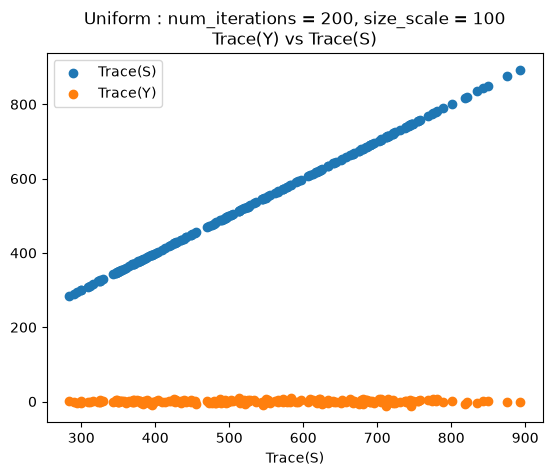

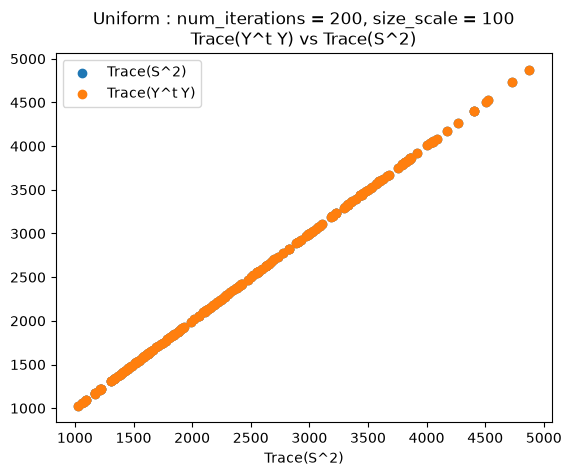


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 8.480574184996749e-07
max : 0.04928419561585449
sum : 1.117483529803538
mean : 0.005587417649017689
std : 0.00774056416124831
norm : 0.13500782904628614


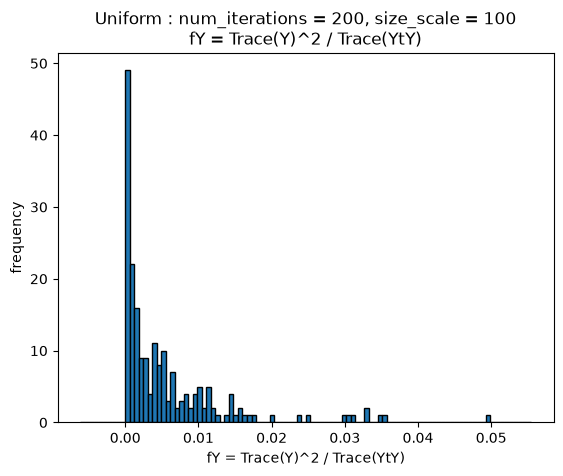


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 78.27859296540849
max : 163.65213228738529
sum : 23654.877018094136
mean : 118.27438509047067
std : 22.350303341461277
norm : 1702.2553408924462


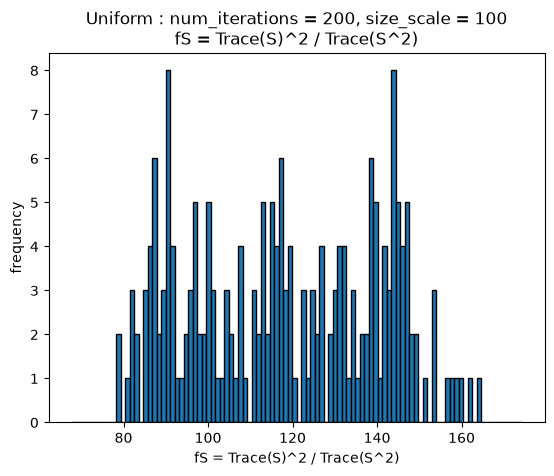

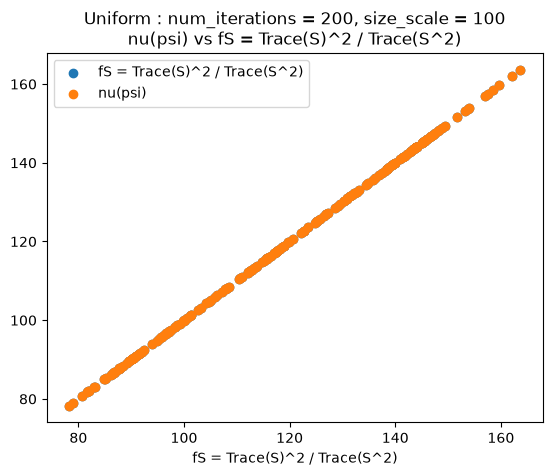


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 6.248312802700137e-09
max : 0.0005075675454469819
sum : 0.009863781760791699
mean : 4.93189088039585e-05
std : 7.037783034448572e-05
norm : 0.0012153512882792684


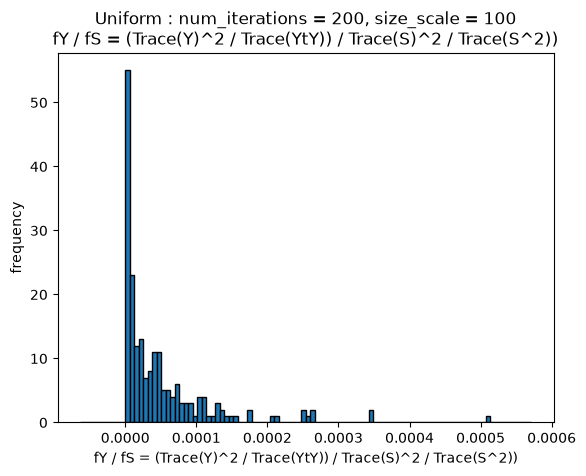


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


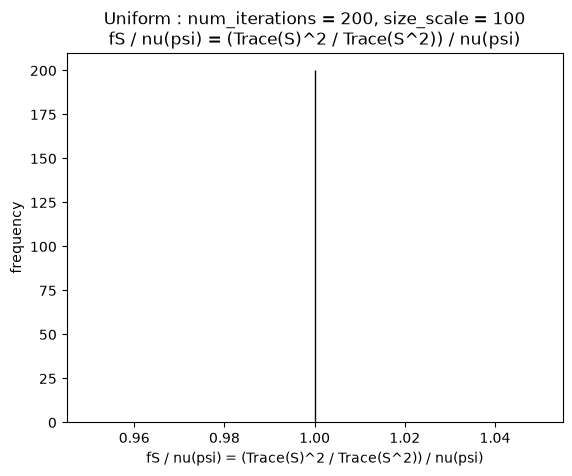


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.022529259762517316
max : 0.018514880571017918
sum : 0.09007648171052794
mean : 0.00045038240855263973
std : 0.007008285417277525
norm : 0.09931657344467588


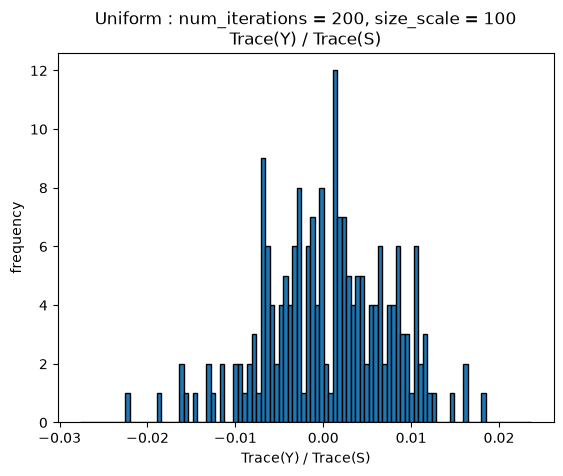


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999988
max : 1.0000000000000016
sum : 200.0
mean : 1.0
std : 5.377423412472531e-16
norm : 14.142135623730951


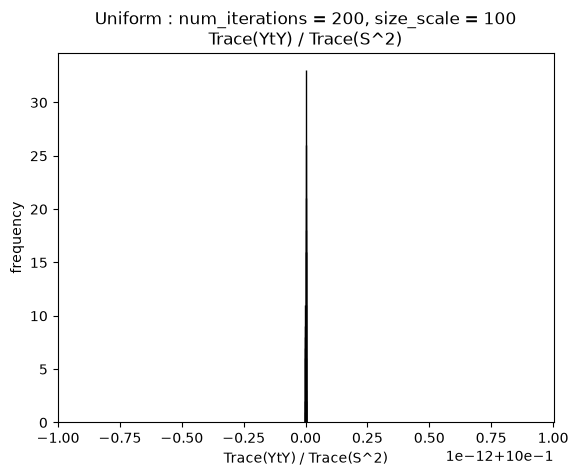

In [3]:
prefix = "Uniform : num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_u_ss_100_ni_200, prefix)

# 2. Normal

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_normal"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = True 

xx_normal_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

Y.shape =  (232, 137) , mu_Y.shape =  (137,)
** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  8.441463904945266 , trace_S =  1908.1026873227427 , trace_Y / trace_S =  0.0044240092323277825
trace_YtY =  31553.868959610776 , trace_Ssquared =  31553.868959610765 , trace_YtY / trace_Ssquared =  1.0000000000000004
(trace_Y ** 2) / (trace_YtY * nu_psi) =  1.957185768772145e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
0 1.9571857687721453e-05 1.0
Y.shape =  (229, 161) , mu_Y.shape =  (161,)
** calculate_nu_cpu ** running on CPU
1 N =  229 , d =  161
trace_Y =  0.011166296234154771 , trace_S =  2196.754109019407 , trace_Y / trace_S =  5.083088811946828e-06
trace_YtY =  36856.1766574188 , trace_Ssquared =  36856.176657418815 , trace_YtY / trace_Ssquared =  0.9999999999999996
(trace_Y ** 2) / (trace_YtY * nu_psi) =  2.5837791870139025e-11
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 2.583779187013903e-11 1.0
Y.shape =  (202, 140) , mu_Y.shape =  (140,)
** calc

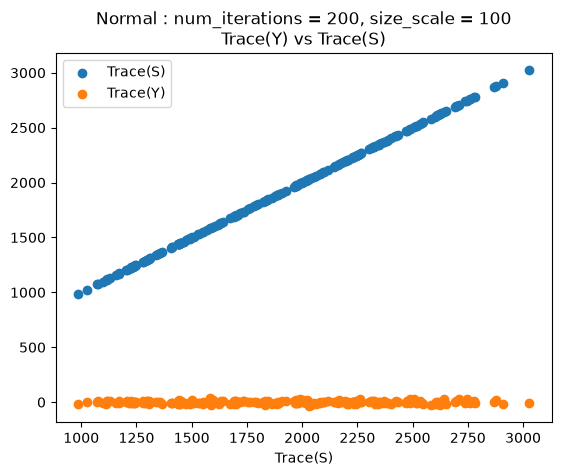

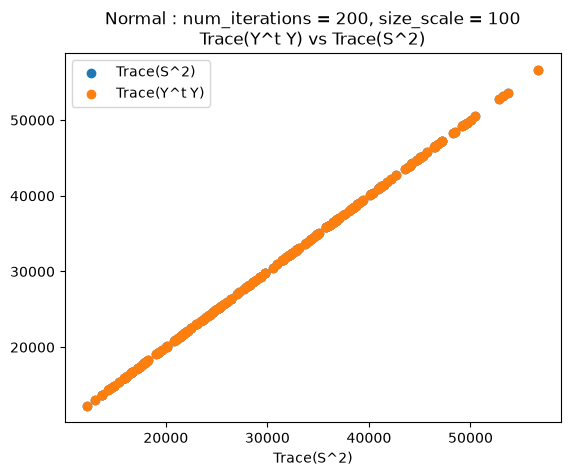


 fY = Trace(Y)^2 / Trace(YtY) 

shape : (200,)
min : 3.383046829514284e-09
max : 0.048824233636329865
sum : 0.9782761522857935
mean : 0.0048913807614289675
std : 0.006908381989202867
norm : 0.11970910363211311


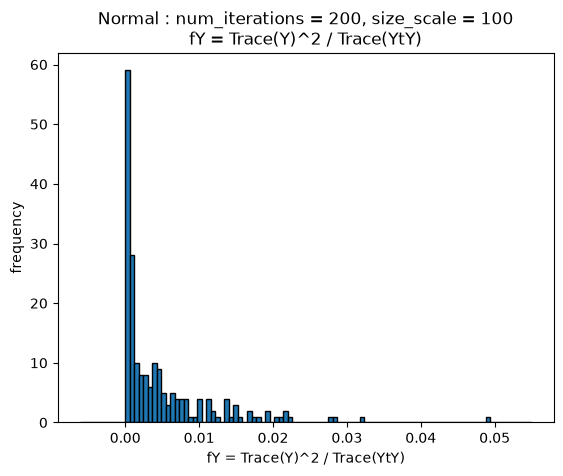


 fS = Trace(S)^2 / Trace(S^2) 

shape : (200,)
min : 79.34070682794727
max : 161.78459333631855
sum : 23835.208491611676
mean : 119.17604245805838
std : 21.509845107768136
norm : 1712.6355439803945


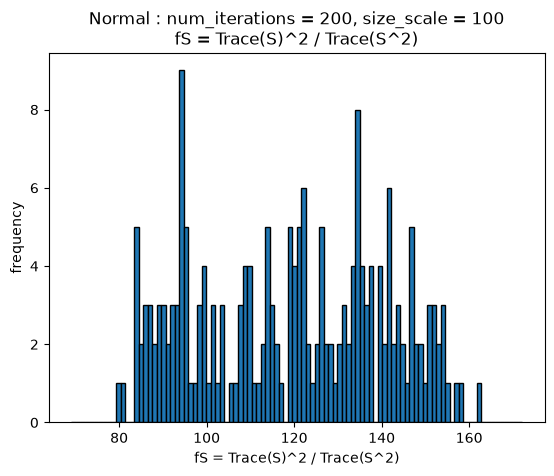

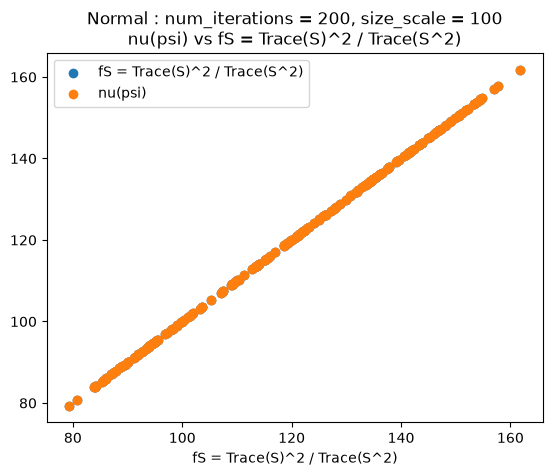


 fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2)) 

shape : (200,)
min : 2.583779187013903e-11
max : 0.0004474717785465196
sum : 0.008699467277495676
mean : 4.349733638747838e-05
std : 6.438830425505107e-05
norm : 0.0010988969012283617


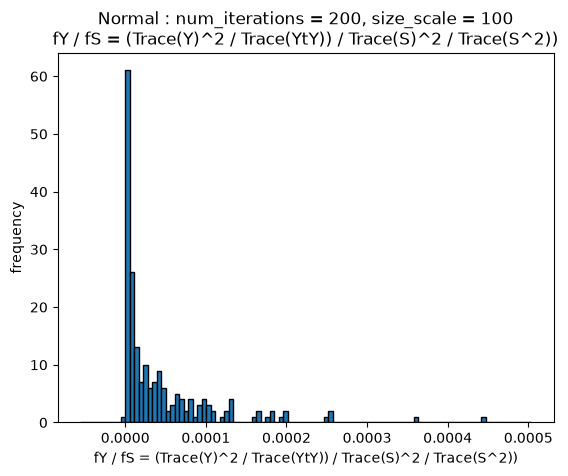


 fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi) 

shape : (200,)
min : 1.0
max : 1.0
sum : 200.0
mean : 1.0
std : 0.0
norm : 14.142135623730951


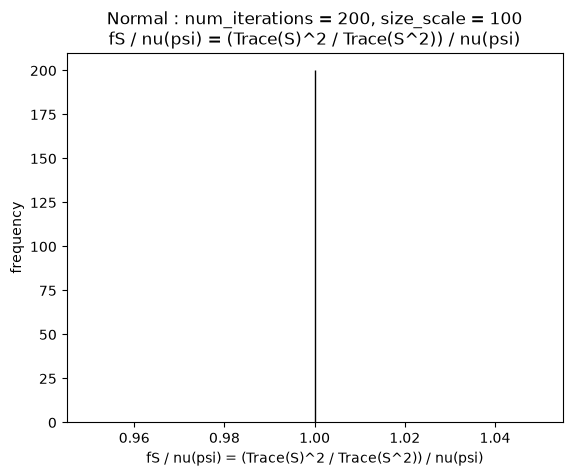


 Trace(Y) / Trace(S) 

shape : (200,)
min : -0.018938961426694295
max : 0.02115352874927773
sum : -0.05527293030170441
mean : -0.00027636465150852207
std : 0.006589458169445722
norm : 0.09327093479479916


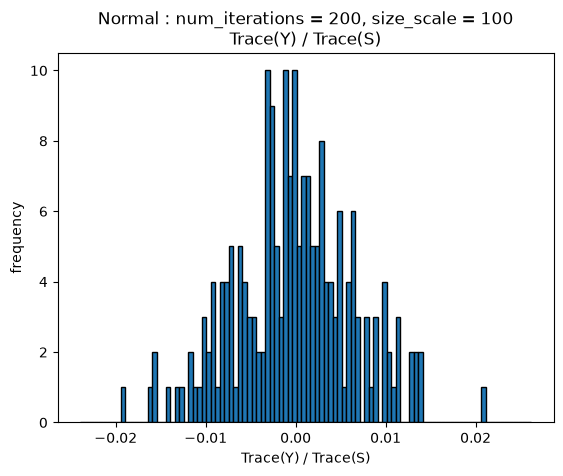


 Trace(YtY) / Trace(S^2) 

shape : (200,)
min : 0.9999999999999986
max : 1.0000000000000016
sum : 200.00000000000003
mean : 1.0000000000000002
std : 5.704429186199679e-16
norm : 14.142135623730953


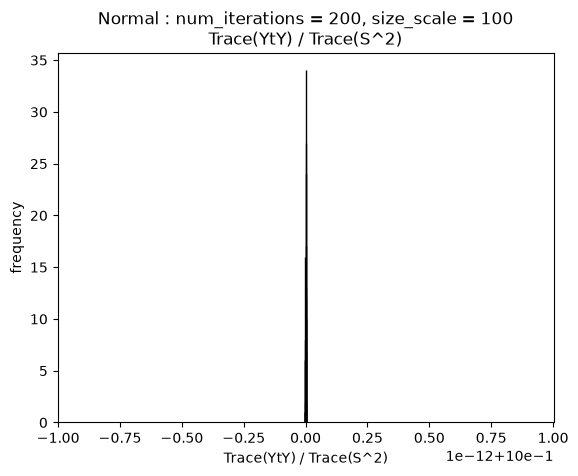

In [3]:
prefix = "Normal : num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_normal_ss_100_ni_200, prefix)

# 3. Pareto

In [2]:
this_config = pp.trace_Y_trace_S_experiment_get_default_config()

num_iterations = 200
size_scale = 100

this_config["num_iterations"] = num_iterations 
this_config["use_pareto"] = True 
this_config["size_scale"] = size_scale 
this_config["column_demean"] = True 

min_alpha = 0.1
max_alpha = 3.0
pareto_alpha_vals = np.linspace(min_alpha, max_alpha, num_iterations)
this_config["pareto_alpha_vals"] = pareto_alpha_vals

xx_pareto_ss_100_ni_200 = pp.trace_Y_trace_S_experiment(this_config)

Y.shape =  (232, 137) , mu_Y.shape =  (137,)
** calculate_nu_cpu ** running on CPU
0 N =  232 , d =  137
trace_Y =  -8.976156987034909e+37 , trace_S =  2.0779692259448943e+40 , trace_Y / trace_S =  -0.004319677536587805
trace_YtY =  1.9979256192018338e+80 , trace_Ssquared =  1.9979256192018302e+80 , trace_YtY / trace_Ssquared =  1.0000000000000018
(trace_Y ** 2) / (trace_YtY * nu_psi) =  1.8659614020101252e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  0.9999999999999999
0 1.865961402010125e-05 1.0
Y.shape =  (166, 162) , mu_Y.shape =  (162,)
** calculate_nu_cpu ** running on CPU
1 N =  166 , d =  162
trace_Y =  -1.71440615171039e+33 , trace_S =  2.837290664754839e+35 , trace_Y / trace_S =  -0.006042405781709102
trace_YtY =  2.1287154811130512e+70 , trace_Ssquared =  2.128715481113054e+70 , trace_YtY / trace_Ssquared =  0.9999999999999987
(trace_Y ** 2) / (trace_YtY * nu_psi) =  3.651066763083162e-05
(trace_S ** 2) / (trace_Squared * nu_psi) =  1.0
1 3.651066763083163e-05 1.0
Y.shape

In [3]:
prefix = "Pareto : " + str(np.min(pareto_alpha_vals)) + " <= alpha <= " + str(np.max(pareto_alpha_vals)) + "\n"
prefix += "num_iterations = " + str(num_iterations) + ", size_scale = " + str(size_scale) + "\n"
#prefix = str(np.min(pareto_alpha_vals)) + " <= alpha <= " + str(np.max(pareto_alpha_vals)) + "\n"
pp.trace_Y_trace_S_experiment_plot_one(xx_pareto_ss_100_ni_200, prefix)

KeyError: 'trace_Y_all_squared_over_trace_YtY_vals'

In [ ]:


num_iterations = 200
size_scale = 100
#d_vals = 100 * np.ones(num_iterations)
use_uniform = True
use_normal = False
use_pareto = False
column_demean = True
force_square_matrices = False
#verbose = True

trace_S_vals = np.zeros(num_iterations)
trace_Ssquared_vals = np.zeros(num_iterations) 
nu_psi_vals = np.zeros(num_iterations)
trace_Y_vals = np.zeros(num_iterations)
trace_YtY_vals = np.zeros(num_iterations)
fY_vals = np.zeros(num_iterations)
fS_vals = np.zeros(num_iterations)
fY_over_fS_vals = np.zeros(num_iterations)
fS_over_nu_psi_vals = np.zeros(num_iterations)
trace_Y_over_trace_S_vals = np.zeros(num_iterations)
trace_YtY_over_trace_Ssquared_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    d = int(size_scale * (1.0 + np.random.uniform(0,1)))
    N = d + int(size_scale * np.random.uniform(0,1))
    if force_square_matrices:
        N = d
    Y = np.zeros((N,d))

    if use_uniform:
        Y = np.random.uniform(0,1,(Y.shape[0],Y.shape[1])) - 0.5

    if column_demean:
        mu_Y = Y.sum(axis=0) / Y.shape[0]
        print("Y.shape = ", Y.shape, ", mu_Y.shape = ", mu_Y.shape)
        Y = Y - mu_Y

    # do SVD
    U, S, Vh = np.linalg.svd(Y, full_matrices=True)

    trace_S = sum(S) 
    trace_Ssquared = sum(S*S) 
    nu_psi = pp.calculate_nu(S)
    trace_Y = np.trace(Y)
    trace_YtY = np.trace(Y.T @ Y)
    fY = (trace_Y ** 2) / trace_YtY
    fS = (trace_S ** 2) / trace_Ssquared
    fY_over_fS = fY / fS
    fS_over_nu_psi = fS / nu_psi
    trace_Y_over_trace_S = trace_Y / trace_S
    trace_YtY_over_trace_Ssquared = trace_YtY / trace_Ssquared
    

    print(i, "N = ", N, ", d = ", d)
    print("trace_Y = ", trace_Y, ", trace_S = ", trace_S, ", trace_Y / trace_S = ", trace_Y / trace_S)
    print("trace_YtY = ", trace_YtY, ", trace_Ssquared = ", trace_Ssquared, ", trace_YtY / trace_Ssquared = ", trace_YtY / trace_Ssquared)
    print("(trace_Y ** 2) / (trace_YtY * nu_psi) = ", (trace_Y ** 2) / (trace_YtY * nu_psi))
    print("(trace_S ** 2) / (trace_Squared * nu_psi) = ", (trace_S ** 2) / (trace_Ssquared * nu_psi))
    print(i, fY_over_fS, fS_over_nu_psi)

    trace_S_vals[i] = trace_S
    trace_Ssquared_vals[i] = trace_Ssquared 
    nu_psi_vals[i] = nu_psi
    trace_Y_vals[i] = trace_Y
    trace_YtY_vals[i] = trace_YtY
    fY_vals[i] = fY
    fS_vals[i] = fS
    fY_over_fS_vals[i] = fY_over_fS
    fS_over_nu_psi_vals[i] = fS_over_nu_psi
    trace_Y_over_trace_S_vals[i] = trace_Y_over_trace_S
    trace_YtY_over_trace_Ssquared_vals[i] = trace_YtY_over_trace_Ssquared
    

    



In [ ]:
pp.plot_histogram(fY_vals)
pp.plot_histogram(fS_vals)
pp.plot_histogram(fY_over_fS_vals)
pp.plot_histogram(fS_over_nu_psi_vals)
pp.plot_histogram(trace_Y_over_trace_S_vals)
pp.plot_histogram(trace_YtY_over_trace_Ssquared_vals)

In [ ]:
def trace_Y_trace_S_experiment_spare(this_config : dict) -> dict:

    num_iterations = this_config["num_iterations"]
    size_scale = this_config["size_scale"]
    use_uniform = this_config["use_uniform"]
    use_normal = this_config["use_normal"]
    use_pareto = this_config["use_pareto"]
    column_demean = this_config["column_demean"]
    force_square_matrices = this_config["force_square_matrices"]

    trace_S_vals = np.zeros(num_iterations)
    trace_Ssquared_vals = np.zeros(num_iterations) 
    nu_psi_vals = np.zeros(num_iterations)
    trace_Y_vals = np.zeros(num_iterations)
    trace_YtY_vals = np.zeros(num_iterations)
    fY_vals = np.zeros(num_iterations)
    fS_vals = np.zeros(num_iterations)
    fY_over_fS_vals = np.zeros(num_iterations)
    fS_over_nu_psi_vals = np.zeros(num_iterations)
    trace_Y_over_trace_S_vals = np.zeros(num_iterations)
    trace_YtY_over_trace_Ssquared_vals = np.zeros(num_iterations)

    for i in range(num_iterations):
        d = int(size_scale * (1.0 + np.random.uniform(0,1)))
        N = d + int(size_scale * np.random.uniform(0,1))
        if force_square_matrices:
            N = d
        Y = np.zeros((N,d))

        if use_uniform:
            Y = np.random.uniform(0,1,(Y.shape[0],Y.shape[1])) - 0.5

        if column_demean:
            mu_Y = Y.sum(axis=0) / Y.shape[0]
            print("Y.shape = ", Y.shape, ", mu_Y.shape = ", mu_Y.shape)
            Y = Y - mu_Y

        # do SVD
        U, S, Vh = np.linalg.svd(Y, full_matrices=True)

        trace_S = sum(S) 
        trace_Ssquared = sum(S*S) 
        nu_psi = pp.calculate_nu(S)
        trace_Y = np.trace(Y)
        trace_YtY = np.trace(Y.T @ Y)
        fY = (trace_Y ** 2) / trace_YtY
        fS = (trace_S ** 2) / trace_Ssquared
        fY_over_fS = fY / fS
        fS_over_nu_psi = fS / nu_psi
        trace_Y_over_trace_S = trace_Y / trace_S
        trace_YtY_over_trace_Ssquared = trace_YtY / trace_Ssquared
    
        print(i, "N = ", N, ", d = ", d)
        print("trace_Y = ", trace_Y, ", trace_S = ", trace_S, ", trace_Y / trace_S = ", trace_Y / trace_S)
        print("trace_YtY = ", trace_YtY, ", trace_Ssquared = ", trace_Ssquared, ", trace_YtY / trace_Ssquared = ", trace_YtY / trace_Ssquared)
        print("(trace_Y ** 2) / (trace_YtY * nu_psi) = ", (trace_Y ** 2) / (trace_YtY * nu_psi))
        print("(trace_S ** 2) / (trace_Squared * nu_psi) = ", (trace_S ** 2) / (trace_Ssquared * nu_psi))
        print(i, fY_over_fS, fS_over_nu_psi)

        trace_S_vals[i] = trace_S
        trace_Ssquared_vals[i] = trace_Ssquared 
        nu_psi_vals[i] = nu_psi
        trace_Y_vals[i] = trace_Y
        trace_YtY_vals[i] = trace_YtY
        fY_vals[i] = fY
        fS_vals[i] = fS
        fY_over_fS_vals[i] = fY_over_fS
        fS_over_nu_psi_vals[i] = fS_over_nu_psi
        trace_Y_over_trace_S_vals[i] = trace_Y_over_trace_S
        trace_YtY_over_trace_Ssquared_vals[i] = trace_YtY_over_trace_Ssquared
	
    results_dict = {
        "trace_S_vals" : trace_S_vals,
        "trace_Ssquared_vals" :  trace_Ssquared_vals,
        "nu_psi_vals" : nu_psi_vals,
        "trace_Y_vals" : trace_Y_vals,
        "trace_YtY_vals" : trace_YtY_vals,
        "fY_vals" : fY_vals,
        "fS_vals" : fS_vals,
        "fY_over_fS_vals" : fY_over_fS_vals,
        "fS_over_nu_psi_vals" : fS_over_nu_psi_vals,
        "trace_Y_over_trace_S_vals" : trace_Y_over_trace_S_vals,
        "trace_YtY_over_trace_Ssquared_vals" : trace_YtY_over_trace_Ssquared_vals
    }

    return results_dict

In [ ]:
def trace_Y_trace_S_experiment_get_default_config_spare() -> dict:
    
    # generate the default config for trace_Y_trace_S_experiment

    default_config = {}

    default_config["num_iterations"] = 0
    default_config["size_scale"] = 0
    default_config["use_uniform"] = False
    default_config["use_normal"] = False
    default_config["use_pareto"] = False
    default_config["column_demean"] = False
    default_config["force_square_matrices"] = False 

    return default_config

In [ ]:

def trace_Y_trace_S_experiment_plot_one_spare(results_dict : dict, prefix : str):

    trace_S_vals = results_dict["trace_S_vals"]
    trace_Ssquared_vals = results_dict["trace_Ssquared_vals"]
    nu_psi_vals = results_dict["nu_psi_vals"]
    trace_Y_vals = results_dict["trace_Y_vals"]
    trace_YtY_vals = results_dict["trace_YtY_vals"]
    fY_vals = results_dict["fY_vals"]
    fS_vals = results_dict["fS_vals"]
    fY_over_fS_vals = results_dict["fY_over_fS_vals"]
    fS_over_nu_psi_vals = results_dict["fS_over_nu_psi_vals"]
    trace_Y_over_trace_S_vals = results_dict["trace_Y_over_trace_S_vals"]
    trace_YtY_over_trace_Ssquared_vals = results_dict["trace_YtY_over_trace_Ssquared_vals"]

    this_title = prefix + "Trace(Y) vs Trace(S)"
    plt.scatter(trace_S_vals, trace_S_vals, label = "Trace(S)")
    plt.scatter(trace_S_vals, trace_Y_vals, label = "Trace(Y)")
    plt.xlabel("Trace(S)")
    plt.legend()
    plt.title(this_title)
    plt.show()

    this_title = prefix + "Trace(Y^t Y) vs Trace(S^2)"
    plt.scatter(trace_Ssquared_vals, trace_Ssquared_vals, label = "Trace(S^2)")
    plt.scatter(trace_Ssquared_vals, trace_YtY_vals, label = "Trace(Y^t Y)")
    plt.xlabel("Trace(S^2)")
    plt.legend()
    plt.title(this_title)
    plt.show()
    

    sep = "="*100
    sep = "\n" + sep + "\n"
    rescale_factor=1.0


    fY_text = "fY = Trace(Y)^2 / Trace(YtY)"
    print(sep, fY_text, sep)
    pp.display_stats(fY_vals)
    x_label = fY_text
    y_label = "frequency"
    title = prefix + fY_text
    pp.plot_histogram(fY_vals, rescale_factor, x_label, y_label, title)

    fS_text = "fS = Trace(S)^2 / Trace(S^2)"
    print(sep, fS_text, sep)
    pp.display_stats(fS_vals)    
    x_label = fS_text
    y_label = "frequency"
    title = prefix + fS_text
    pp.plot_histogram(fS_vals, rescale_factor, x_label, y_label, title)

    fY_over_fS_text = "fY / fS = (Trace(Y)^2 / Trace(YtY)) / Trace(S)^2 / Trace(S^2))"
    print(sep, fY_over_fS_text, sep)
    pp.display_stats(fY_over_fS_vals) 
    x_label = fY_over_fS_text
    y_label = "frequency"
    title = prefix + fY_over_fS_text    
    pp.plot_histogram(fY_over_fS_vals, rescale_factor, x_label, y_label, title)

    fS_over_nu_psi_text = "fS / nu(psi) = (Trace(S)^2 / Trace(S^2)) / nu(psi)"
    print(sep, fS_over_nu_psi_text, sep)
    pp.display_stats(fS_over_nu_psi_vals)   
    x_label = fS_over_nu_psi_text
    y_label = "frequency"
    title = prefix + fS_over_nu_psi_text    
    pp.plot_histogram(fS_over_nu_psi_vals, rescale_factor, x_label, y_label, title)

    trace_Y_over_trace_S_text = "Trace(Y) / Trace(S)"
    print(sep, trace_Y_over_trace_S_text, sep)
    pp.display_stats(trace_Y_over_trace_S_vals)   
    x_label = trace_Y_over_trace_S_text
    y_label = "frequency"
    title = prefix + trace_Y_over_trace_S_text    
    pp.plot_histogram(trace_Y_over_trace_S_vals, rescale_factor, x_label, y_label, title)

    trace_YtY_over_trace_Ssquared_text = "Trace(YtY) / Trace(S^2)"
    print(sep, trace_YtY_over_trace_Ssquared_text, sep)
    pp.display_stats(trace_YtY_over_trace_Ssquared_vals)
    x_label = trace_YtY_over_trace_Ssquared_text
    y_label = "frequency"
    title = prefix + trace_YtY_over_trace_Ssquared_text
    pp.plot_histogram(trace_YtY_over_trace_Ssquared_vals, rescale_factor, x_label, y_label, title)
    